# Citation Intent RAG — Full Pipeline
**Domain-Specific Retrieval-Augmented QA on SciCite + ACL-ARC**

This notebook runs the complete RAG pipeline on Colab:
1. Install dependencies
2. Upload corpus and build FAISS index
3. Run RAG QA on evaluation questions
4. Evaluate retrieval quality and answer faithfulness
5. Download results

## Step 1 — Install Dependencies

In [1]:
!pip install openai python-dotenv sentence-transformers faiss-cpu scikit-learn matplotlib seaborn tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 83.5 MB/s eta 0:00:00


## Step 2 — Configuration

In [ ]:
OPENROUTER_API_KEY = "opne router key"
DEFAULT_MODEL      = "google/gemini-2.0-flash-001"
ENCODER_MODEL      = "allenai-specter"
TOP_K              = 5    # number of passages to retrieve per query

import os, json, time, re
import numpy as np
import faiss
from tqdm import tqdm
from openai import OpenAI

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY
)
print("Config ready.")

Config ready.


## Step 3 — Upload Corpus and Build FAISS Index

In [3]:
from google.colab import files

print("Upload combined_corpus.json from citation_rag/corpus/")
uploaded = files.upload()  # select combined_corpus.json

with open("combined_corpus.json") as f:
    corpus = json.load(f)

print(f"Corpus loaded: {len(corpus)} entries")

from collections import Counter
label_dist = Counter(c["label"] for c in corpus)
print("Label distribution:")
for label, count in sorted(label_dist.items(), key=lambda x: -x[1]):
    print(f"  {label:20s}: {count}")

Upload combined_corpus.json from citation_rag/corpus/


Saving combined_corpus.json to combined_corpus.json
Corpus loaded: 12910 entries
Label distribution:
  background          : 7371
  method              : 3489
  result              : 1821
  motivation          : 88
  extends             : 72
  future              : 69


In [4]:
from sentence_transformers import SentenceTransformer

texts  = [c["text"]  for c in corpus]
labels = [c["label"] for c in corpus]
ids    = [c["id"]    for c in corpus]

print(f"Loading encoder: {ENCODER_MODEL}")
encoder = SentenceTransformer(ENCODER_MODEL)

print(f"Encoding {len(texts)} passages...")
embs = encoder.encode(
    texts, batch_size=64,
    normalize_embeddings=True,
    show_progress_bar=True
)

index = faiss.IndexFlatIP(embs.shape[1])
index.add(embs.astype("float32"))
print(f"Index built: {index.ntotal} vectors, dim={embs.shape[1]}")

Loading encoder: allenai-specter


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 12910 passages...


Batches:   0%|          | 0/202 [00:00<?, ?it/s]

Index built: 12910 vectors, dim=768


## Step 4 — Core Functions

In [5]:
def detect_intent(question):
      """Keyword-based intent detection from the query to guide label filtering."""
      q = question.lower()
      if any(w in q for w in ["future", "open problem", "direction", "leave to future"]):
          return ["future"]
      if any(w in q for w in ["extend", "built upon", "build on", "foundation"]):
          return ["extends"]
      if any(w in q for w in ["motivat", "limitation", "gap", "fails to", "address"]):
          return ["motivation"]
      if any(w in q for w in ["result", "compare", "outperform", "accuracy", "f1", "score", "baseline", "contrast"]):
          return ["result"]
      if any(w in q for w in ["method", "tool", "dataset", "used", "apply", "following", "backbone", "technique"]):
          return ["method"]
      if any(w in q for w in ["background", "context", "prior", "first introduced", "situate"]):
          return ["background"]
      return None  # no label detected — fall back to unfiltered retrieval


def retrieve(query, k=TOP_K, use_label_filter=True, large_k=100):
      q_emb = encoder.encode([query], normalize_embeddings=True).astype("float32")
      scores, idxs = index.search(q_emb, large_k)

      results = [
          {"text": texts[i], "label": labels[i], "id": ids[i], "score": float(scores[0][j])}
          for j, i in enumerate(idxs[0])
      ]

      if use_label_filter:
          detected = detect_intent(query)
          if detected:
              filtered = [r for r in results if r["label"] in detected]
              if len(filtered) >= k:
                  return filtered[:k]
              # not enough filtered results — pad with unfiltered remainder
              filtered_ids = {r["id"] for r in filtered}
              remaining    = [r for r in results if r["id"] not in filtered_ids]
              return (filtered + remaining)[:k]

      return results[:k]


def call_llm(messages, model=DEFAULT_MODEL, max_tokens=256, retries=3):
      for attempt in range(retries):
          try:
              resp = client.chat.completions.create(
                  model=model,
                  messages=messages,
                  max_tokens=max_tokens,
                  temperature=0.0
              )
              return resp.choices[0].message.content.strip()
          except Exception as e:
              if attempt < retries - 1:
                  time.sleep(2 ** attempt)
              else:
                  return f"ERROR: {e}"


def rag_qa_prompt(question, retrieved):
      passage_block = ""
      for i, p in enumerate(retrieved, 1):
          passage_block += f'[{i}] ({p["label"]}) "{p["text"]}"\n\n'
      return [
          {"role": "system", "content": (
              "You are a research assistant with access to a corpus of scientific citation sentences. "
              "Answer the user's question using ONLY the retrieved passages below. "
              "Reference passages by their number [1], [2], etc. "
              "If the passages do not contain enough information, say so explicitly. "
              "Do not use knowledge outside the provided passages."
          )},
          {"role": "user", "content": (
              f"Question: {question}\n\n"
              f"Retrieved passages:\n{passage_block}"
              "Answer:"
          )}
      ]


print("Core functions ready.")

Core functions ready.


## Step 5 — Retrieval Smoke Test

In [6]:
test_query = "papers that use AI to write"
results = retrieve(test_query, k=3)

print(f"Query: {test_query}\n")
for i, r in enumerate(results, 1):
    print(f"[{i}] score={r['score']:.3f} | label={r['label']}")
    print(f"    {r['text'][:120]}")
    print()

Query: papers that use AI to write

[1] score=0.786 | label=background
    gov/pubmed/) and both the total number of publications and the growth rate of the number of publications are increasing 

[2] score=0.785 | label=background
    The paradigm is `` write many , read many '' ( Cunningham and Leuf , 2001 ) .

[3] score=0.778 | label=background
    Its work has been published in a number of journals and at several international conferences ([2], [3], [4]).



## Step 6 — Evaluation Questions

In [7]:
qa_pairs = [
    {
        "id": "q001",
        "question": "Find citations where a method or tool from a prior paper was directly used.",
        "expected_labels": ["method"],
        "reference_answer": "Method citations include sentences like 'We use the approach of...' where the citing paper adopts a technique from the cited work."
    },
    {
        "id": "q002",
        "question": "Which citations provide background context or motivate the need for a new approach?",
        "expected_labels": ["background", "motivation"],
        "reference_answer": "Background citations establish context such as 'This problem was first studied by...' without the citing paper directly using the cited method."
    },
    {
        "id": "q003",
        "question": "Find citations where the results of a prior paper are compared or contrasted with new results.",
        "expected_labels": ["result"],
        "reference_answer": "Result-comparison citations include phrases like 'Our model outperforms [X] by...' or 'We achieve higher F1 than [X]...'"
    },
    {
        "id": "q004",
        "question": "Which citations describe papers that extended or built upon prior foundational work?",
        "expected_labels": ["extends"],
        "reference_answer": "Extension citations say things like 'We extend the framework of [X]...' indicating a direct incremental contribution."
    },
    {
        "id": "q005",
        "question": "Find citations that suggest future research directions or open problems.",
        "expected_labels": ["future"],
        "reference_answer": "Future citations include sentences like 'We leave exploration of [X] to future work'."
    },
    {
        "id": "q006",
        "question": "Which citation sentences use transformer-based models as a method?",
        "expected_labels": ["method"],
        "reference_answer": "These are method citations where the citing paper adopts a transformer variant, e.g. 'We fine-tune BERT on our dataset...'"
    },
    {
        "id": "q007",
        "question": "Find citations where a dataset from a prior paper is used in experiments.",
        "expected_labels": ["method"],
        "reference_answer": "Dataset-use citations are a subtype of method citations, e.g. 'We evaluate on the dataset introduced by [X]...'"
    },
    {
        "id": "q008",
        "question": "Which citations compare accuracy or F1 scores against a baseline from another paper?",
        "expected_labels": ["result"],
        "reference_answer": "These contain numeric comparisons like 'achieves 92.3% accuracy, compared to [X]s 89.1%...'"
    },
    {
        "id": "q009",
        "question": "Find citations where the motivation for a new approach is grounded in a limitation of prior work.",
        "expected_labels": ["motivation", "background"],
        "reference_answer": "Motivation citations identify gaps, e.g. 'While [X] addresses A, it fails to handle B, which we tackle in this paper.'"
    },
    {
        "id": "q010",
        "question": "What citation sentences discuss neural machine translation or sequence-to-sequence models?",
        "expected_labels": ["background", "method", "result"],
        "reference_answer": "Citations mentioning NMT or seq2seq span background (introducing the concept), method (using an NMT framework), or result (comparing BLEU scores)."
    }
]

print(f"Loaded {len(qa_pairs)} evaluation questions.")

Loaded 10 evaluation questions.


## Step 7 — Run RAG QA on All Questions

In [8]:
rag_results = []

for qa in tqdm(qa_pairs, desc="RAG QA"):
    retrieved = retrieve(qa["question"], k=TOP_K)
    prompt    = rag_qa_prompt(qa["question"], retrieved)
    answer    = call_llm(prompt, max_tokens=256)
    time.sleep(3)  # rate limit buffer

    rag_results.append({
        "id":               qa["id"],
        "question":         qa["question"],
        "expected_labels":  qa["expected_labels"],
        "reference_answer": qa["reference_answer"],
        "retrieved":        retrieved,
        "answer":           answer
    })

print("\nRAG QA complete.")
print(f"\nSample — {rag_results[0]['question']}")
print(f"Answer: {rag_results[0]['answer'][:300]}")

RAG QA: 100%|██████████| 10/10 [00:38<00:00,  3.86s/it]


RAG QA complete.

Sample — Find citations where a method or tool from a prior paper was directly used.
Answer: Passage [3] describes using Salton's cosine for normalization [3]. Passage [5] describes using title pages with slight modifications from a previous study [5].


## Step 8 — Retrieval Evaluation (Label Precision@k)

In [9]:
import pandas as pd

retrieval_scores = []

for r in rag_results:
    expected        = set(r["expected_labels"])
    retrieved_labels = [p["label"] for p in r["retrieved"]]
    k               = len(retrieved_labels)
    label_precision = sum(1 for l in retrieved_labels if l in expected) / k

    retrieval_scores.append({
        "id":                r["id"],
        "question":          r["question"][:60] + "...",
        "expected_labels":   ", ".join(r["expected_labels"]),
        "retrieved_labels":  ", ".join(retrieved_labels),
        "label_precision@k": round(label_precision, 3)
    })

df = pd.DataFrame(retrieval_scores)
print(df[["id", "expected_labels", "label_precision@k"]].to_string(index=False))
print(f"\nMean Label Precision@{TOP_K}: {df['label_precision@k'].mean():.3f}")

  id            expected_labels  label_precision@k
q001                     method                1.0
q002     background, motivation                0.8
q003                     result                1.0
q004                    extends                0.6
q005                     future                0.2
q006                     method                1.0
q007                     method                1.0
q008                     result                1.0
q009     motivation, background                0.6
q010 background, method, result                1.0

Mean Label Precision@5: 0.820


## Step 9 — Faithfulness Evaluation (LLM-as-Judge)

In [10]:
def faithfulness_prompt(question, retrieved, answer):
    passage_block = "\n".join(f"[{i+1}] {p['text']}" for i, p in enumerate(retrieved))
    return [
        {"role": "system", "content": (
            "You are an evaluator. Given retrieved passages and a generated answer, "
            "rate whether every claim in the answer is supported by the passages. "
            "Reply with ONLY: 'Score: X. Reason: one sentence.' where X is 1-5. "
            "1=completely unsupported, 5=fully grounded in the passages."
        )},
        {"role": "user", "content": (
            f"Passages:\n{passage_block}\n\n"
            f"Answer:\n{answer}\n\n"
            "Faithfulness score:"
        )}
    ]


def parse_score(raw):
    m = re.search(r"Score:\s*(\d)", raw)
    if m:
        s = int(m.group(1))
        return s if 1 <= s <= 5 else None
    m = re.search(r"\b([1-5])\b", raw)
    return int(m.group(1)) if m else None


faithfulness_scores = []

for r in tqdm(rag_results, desc="Faithfulness eval"):
    prompt = faithfulness_prompt(r["question"], r["retrieved"], r["answer"])
    raw    = call_llm(prompt, max_tokens=64)
    score  = parse_score(raw)
    faithfulness_scores.append({"id": r["id"], "score": score, "raw": raw})
    time.sleep(3)

valid_scores = [s["score"] for s in faithfulness_scores if s["score"] is not None]
print(f"\nFaithfulness scores: {[s['score'] for s in faithfulness_scores]}")
print(f"Mean Faithfulness: {sum(valid_scores)/len(valid_scores):.2f} / 5")

Faithfulness eval: 100%|██████████| 10/10 [00:40<00:00,  4.07s/it]


Faithfulness scores: [5, 1, 5, 5, 1, 5, 5, 5, 1, 5]
Mean Faithfulness: 3.80 / 5


## Step 10 — Confusion Matrix: Retrieved Label Distribution

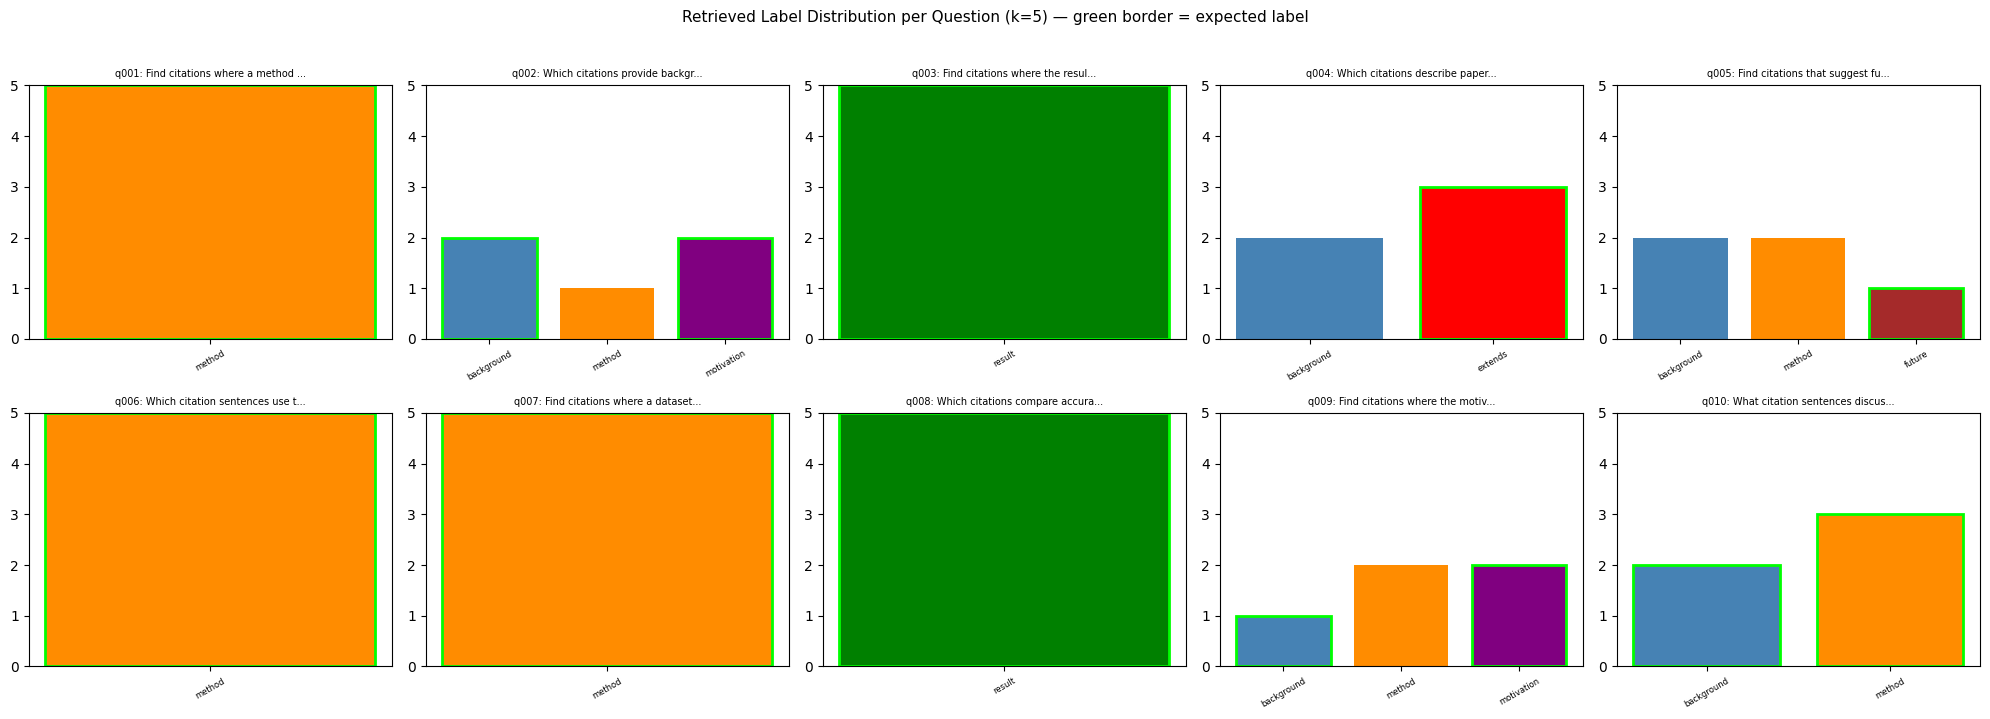

Saved: retrieval_label_dist.png


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar chart: retrieved label distribution per question
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

all_labels = ["background", "method", "result", "extends", "motivation", "future"]
colors     = {"background": "steelblue", "method": "darkorange", "result": "green",
              "extends": "red", "motivation": "purple", "future": "brown"}

for ax, r in zip(axes, rag_results):
    label_counts = Counter(p["label"] for p in r["retrieved"])
    bar_labels   = [l for l in all_labels if l in label_counts]
    bar_values   = [label_counts[l] for l in bar_labels]
    bar_colors   = [colors.get(l, "gray") for l in bar_labels]
    ax.bar(bar_labels, bar_values, color=bar_colors)
    ax.set_title(r["id"] + ": " + r["question"][:30] + "...", fontsize=7)
    ax.set_ylim(0, TOP_K)
    ax.tick_params(axis="x", labelsize=6, rotation=30)
    # mark expected labels in green box
    for label in r["expected_labels"]:
        if label in bar_labels:
            idx = bar_labels.index(label)
            ax.get_children()[idx].set_edgecolor("lime")
            ax.get_children()[idx].set_linewidth(2)

plt.suptitle(f"Retrieved Label Distribution per Question (k={TOP_K}) — green border = expected label",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("retrieval_label_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: retrieval_label_dist.png")

## Step 11 — Full Results Display

In [12]:
for r, f in zip(rag_results, faithfulness_scores):
    print("=" * 70)
    print(f"[{r['id']}] {r['question']}")
    print(f"Expected label(s): {', '.join(r['expected_labels'])}")
    print()
    print("Retrieved passages:")
    for i, p in enumerate(r["retrieved"], 1):
        print(f"  [{i}] ({p['label']}, score={p['score']:.3f}) {p['text'][:100]}")
    print()
    print(f"Answer: {r['answer']}")
    print(f"Faithfulness: {f['score']}/5 — {f['raw'][:80]}")
    print()

[q001] Find citations where a method or tool from a prior paper was directly used.
Expected label(s): method

Retrieved passages:
  [1] (method, score=0.883) Next, backward and forward searches were performed for each relevant article, according to the guide
  [2] (method, score=0.867) This study was conducted and reported using the following checklists: AMSTAR (Assessment of Multiple
  [3] (method, score=0.866) Salton’s cosine was used for normalization in both the cited and the citing directions (Salton & McG
  [4] (method, score=0.864) Non-systematic reviews “Review” Methods Although there is no single database reliably showing the tr
  [5] (method, score=0.857) The title pages were, with slight modifications, the same as those used in the previous study by Sve

Answer: Passage [3] describes using Salton's cosine for normalization [3]. Passage [5] describes using title pages with slight modifications from a previous study [5].
Faithfulness: 5/5 — Score: 5. Reason:Both claims are dir

## Step 12 — Save and Download Results

In [13]:
output = {
    "rag_results":         rag_results,
    "retrieval_scores":    retrieval_scores,
    "faithfulness_scores": faithfulness_scores,
    "summary": {
        "mean_label_precision_at_k": round(df["label_precision@k"].mean(), 4),
        "mean_faithfulness":         round(sum(valid_scores)/len(valid_scores), 4),
        "k":                         TOP_K,
        "model":                     DEFAULT_MODEL,
        "encoder":                   ENCODER_MODEL,
        "corpus_size":               len(corpus)
    }
}

with open("rag_results.json", "w") as f:
    json.dump(output, f, indent=2)

print("Summary:")
for k, v in output["summary"].items():
    print(f"  {k}: {v}")

from google.colab import files
files.download("rag_results.json")
files.download("retrieval_label_dist.png")
print("\nDownloads started. Save rag_results.json to citation_rag/results/rag/")

Summary:
  mean_label_precision_at_k: 0.82
  mean_faithfulness: 3.8
  k: 5
  model: google/gemini-2.0-flash-001
  encoder: allenai-specter
  corpus_size: 12910


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloads started. Save rag_results.json to citation_rag/results/rag/


---
##Classification on Test Splits

Each condition classifies individual citation sentences from the test splits.
Ground truth label is known for every sentence — **Macro-F1** is the metric.

- **Zero-shot**: LLM sees only the label taxonomy and the sentence
- **Few-shot**: LLM sees the taxonomy + fixed example sentences per class
- **RAG**: LLM sees the taxonomy + top-5 similar training sentences retrieved by FAISS

Datasets:
- SciCite test: 300 stratified samples (from 1859)
- ACL-ARC test: all 139 sentences

In [14]:
##Taxonomies, Prompts and Parse Function for Classification

SCICITE_TAXONOMY = {
    "background": "Provides context, motivation, or situates the work.",
    "method":     "A method, tool, or dataset being used.",
    "result":     "Results are compared or contrasted.",
}

ACL_ARC_TAXONOMY = {
    "background":  "Provides general context or motivation.",
    "method":      "The cited work is used directly.",
    "result":      "Results are compared or contrasted.",
    "extends":     "The citing paper builds on the cited work.",
    "motivation":  "The cited work motivates the research question.",
    "future":      "Suggested as future direction.",
}

SCICITE_DEMOS = [
    {"text": "We follow the preprocessing steps of [CITATION].",       "label": "method"},
    {"text": "[CITATION] first introduced the task of ...",             "label": "background"},
    {"text": "Our model outperforms [CITATION] by 3 F1 points.",        "label": "result"},
]

ACL_ARC_DEMOS = [
    {"text": "We use the parser of [CITATION] to extract dependencies.", "label": "method"},
    {"text": "[CITATION] laid the groundwork for this line of research.","label": "background"},
    {"text": "Our results are significantly better than [CITATION].",    "label": "result"},
    {"text": "We extend the framework proposed by [CITATION].",          "label": "extends"},
    {"text": "As noted by [CITATION], this problem remains open.",       "label": "motivation"},
    {"text": "We leave exploration of [CITATION]'s approach to future work.", "label": "future"},
]


def zs_classify_prompt(sentence, taxonomy):
    label_list = "\n".join(f"- {k}: {v}" for k, v in taxonomy.items())
    return [
        {"role": "system", "content": (
            "You are a scientific document analyst. "
            "Classify the citation intent. "
            f"Reply with exactly one label from this list:\n{label_list}"
        )},
        {"role": "user", "content": f'Citation: "{sentence}"\nLabel:'},
    ]


def fs_classify_prompt(sentence, taxonomy, demos):
    label_list = "\n".join(f"- {k}: {v}" for k, v in taxonomy.items())
    demo_block = "\n\n".join(
        f'Citation: "{d["text"]}"\nLabel: {d["label"]}' for d in demos
    )
    return [
        {"role": "system", "content": (
            "You are a scientific document analyst. "
            "Classify the citation intent. "
            f"Reply with exactly one label from this list:\n{label_list}"
        )},
        {"role": "user", "content": f"{demo_block}\n\nCitation: \"{sentence}\"\nLabel:"},
    ]


def rag_classify_prompt(sentence, taxonomy, retrieved_train):
    label_list = "\n".join(f"- {k}: {v}" for k, v in taxonomy.items())
    demo_block = "\n\n".join(
        f'Citation: "{p["text"]}"\nLabel: {p["label"]}' for p in retrieved_train
    )
    return [
        {"role": "system", "content": (
            "You are a scientific document analyst. "
            "Classify the citation intent. "
            f"Reply with exactly one label from this list:\n{label_list}"
        )},
        {"role": "user", "content": f"{demo_block}\n\nCitation: \"{sentence}\"\nLabel:"},
    ]


def parse_label(raw, valid_labels):
    raw = raw.strip().lower()
    for label in valid_labels:
        if label.lower() in raw:
            return label
    return "unknown"


print("complete — taxonomies, prompts and parse function ready.")

complete — taxonomies, prompts and parse function ready.


In [15]:
##Build Training-Only FAISS Index for RAG Classification
# This index is built ONLY on training sentences so test sentences are never
# retrieved as examples — that would be data leakage.

train_corpus = [c for c in corpus if c["split"] == "train"]
train_texts  = [c["text"]  for c in train_corpus]
train_labels = [c["label"] for c in train_corpus]
train_ids    = [c["id"]    for c in train_corpus]

print(f"Training corpus size: {len(train_corpus)} sentences")
print(f"  SciCite train: {sum(1 for c in train_corpus if c['source']=='scicite')}")
print(f"  ACL-ARC train: {sum(1 for c in train_corpus if c['source']=='acl_arc')}")

print(f"\nEncoding training corpus with {ENCODER_MODEL}...")
train_embs = encoder.encode(
    train_texts, batch_size=64,
    normalize_embeddings=True,
    show_progress_bar=True
)

train_index = faiss.IndexFlatIP(train_embs.shape[1])
train_index.add(train_embs.astype("float32"))
print(f"Training index built: {train_index.ntotal} vectors, dim={train_embs.shape[1]}")


def retrieve_train(sentence, k=5):
    """Retrieve k similar sentences from training split only."""
    q = encoder.encode([sentence], normalize_embeddings=True).astype("float32")
    scores, idxs = train_index.search(q, k)
    return [
        {"text": train_texts[i], "label": train_labels[i], "score": float(scores[0][j])}
        for j, i in enumerate(idxs[0])
    ]

Training corpus size: 9882 sentences
  SciCite train: 8194
  ACL-ARC train: 1688

Encoding training corpus with allenai-specter...


Batches:   0%|          | 0/155 [00:00<?, ?it/s]

Training index built: 9882 vectors, dim=768


In [16]:
##Sample Test Splits
from sklearn.model_selection import train_test_split

scicite_test = [c for c in corpus if c["source"] == "scicite" and c["split"] == "test"]
acl_arc_test = [c for c in corpus if c["source"] == "acl_arc" and c["split"] == "test"]

# stratified sample of 300 from SciCite
_, scicite_sample = train_test_split(
    scicite_test,
    test_size=300,
    stratify=[c["label"] for c in scicite_test],
    random_state=42
)

# use all ACL-ARC test sentences (139)
acl_arc_sample = acl_arc_test

print(f"SciCite test sample : {len(scicite_sample)} sentences")
print(f"ACL-ARC test sample : {len(acl_arc_sample)} sentences")

from collections import Counter
print("\nSciCite sample label dist:", dict(Counter(c["label"] for c in scicite_sample)))
print("ACL-ARC sample label dist:", dict(Counter(c["label"] for c in acl_arc_sample)))

SciCite test sample : 300 sentences
ACL-ARC test sample : 139 sentences

SciCite sample label dist: {'result': 42, 'background': 161, 'method': 97}
ACL-ARC sample label dist: {'result': 25, 'background': 71, 'motivation': 7, 'method': 26, 'future': 5, 'extends': 5}


In [17]:
##Run All Three Conditions on Test Splits
# Each sentence gets classified by zero-shot, few-shot, and RAG.
# Results are cached to disk after every prediction.

import os

def run_classification(sample, taxonomy, demos, source_name, cache_dir="classification_results"):
    os.makedirs(cache_dir, exist_ok=True)
    cache_zs = f"{cache_dir}/{source_name}_zero_shot.json"
    cache_fs = f"{cache_dir}/{source_name}_few_shot.json"
    cache_rag = f"{cache_dir}/{source_name}_rag.json"

    # load existing caches
    zs_done  = json.load(open(cache_zs))  if os.path.exists(cache_zs)  else {}
    fs_done  = json.load(open(cache_fs))  if os.path.exists(cache_fs)  else {}
    rag_done = json.load(open(cache_rag)) if os.path.exists(cache_rag) else {}

    labels = list(taxonomy.keys())

    for row in tqdm(sample, desc=f"{source_name}"):
        rid = row["id"]

        # zero-shot
        if rid not in zs_done:
            raw  = call_llm(zs_classify_prompt(row["text"], taxonomy), max_tokens=16)
            pred = parse_label(raw, labels)
            zs_done[rid] = {"label": row["label"], "pred": pred, "raw": raw}
            json.dump(zs_done, open(cache_zs, "w"), indent=2)
            time.sleep(1.5)

        # few-shot
        if rid not in fs_done:
            raw  = call_llm(fs_classify_prompt(row["text"], taxonomy, demos), max_tokens=16)
            pred = parse_label(raw, labels)
            fs_done[rid] = {"label": row["label"], "pred": pred, "raw": raw}
            json.dump(fs_done, open(cache_fs, "w"), indent=2)
            time.sleep(1.5)

        # RAG — retrieve from training index, then classify
        if rid not in rag_done:
            retrieved = retrieve_train(row["text"], k=5)
            # Filter retrieved examples to only include labels present in the current taxonomy
            filtered_retrieved = [p for p in retrieved if p["label"] in labels]
            raw  = call_llm(rag_classify_prompt(row["text"], taxonomy, filtered_retrieved), max_tokens=16)
            pred = parse_label(raw, labels)
            rag_done[rid] = {"label": row["label"], "pred": pred, "raw": raw,
                             "retrieved_labels": [r["label"] for r in retrieved]}
            json.dump(rag_done, open(cache_rag, "w"), indent=2)
            time.sleep(1.5)

    return list(zs_done.values()), list(fs_done.values()), list(rag_done.values())


print("Running classification on SciCite test split...")
sc_zs, sc_fs, sc_rag = run_classification(
    scicite_sample, SCICITE_TAXONOMY, SCICITE_DEMOS, "scicite"
)

print("\nRunning classification on ACL-ARC test split...")
arc_zs, arc_fs, arc_rag = run_classification(
    acl_arc_sample, ACL_ARC_TAXONOMY, ACL_ARC_DEMOS, "acl_arc"
)

print("\nAll classification done.")

Running classification on SciCite test split...


scicite: 100%|██████████| 300/300 [32:32<00:00,  6.51s/it]



Running classification on ACL-ARC test split...


acl_arc: 100%|██████████| 139/139 [15:03<00:00,  6.50s/it]


All classification done.


In [18]:
##Macro-F1 Results Table
from sklearn.metrics import f1_score, classification_report
import pandas as pd

def macro_f1(results, labels):
    golds = [r["label"] for r in results]
    preds = [r["pred"]  for r in results]
    return f1_score(golds, preds, average="macro", labels=labels, zero_division=0)

sc_labels  = list(SCICITE_TAXONOMY.keys())
# Update arc_labels to only include 'background', 'method', 'result'
arc_labels = ["background", "method", "result"]

rows = [
    {"Condition": "Zero-shot",
     "SciCite Macro-F1": round(macro_f1(sc_zs,  sc_labels),  3),
     "ACL-ARC Macro-F1": round(macro_f1(arc_zs, arc_labels), 3)},
    {"Condition": "Few-shot",
     "SciCite Macro-F1": round(macro_f1(sc_fs,  sc_labels),  3),
     "ACL-ARC Macro-F1": round(macro_f1(arc_fs, arc_labels), 3)},
    {"Condition": "RAG",
     "SciCite Macro-F1": round(macro_f1(sc_rag,  sc_labels),  3),
     "ACL-ARC Macro-F1": round(macro_f1(arc_rag, arc_labels), 3)},
]

df_clf = pd.DataFrame(rows).set_index("Condition")
print("=== Track 1: Classification on Test Splits ===")
print(df_clf.to_string())

print("\n--- SciCite per-class F1 (Zero-shot) ---")
print(classification_report(
    [r["label"] for r in sc_zs],
    [r["pred"]  for r in sc_zs],
    labels=sc_labels, zero_division=0
))

print("\n--- SciCite per-class F1 (Few-shot) ---")
print(classification_report(
    [r["label"] for r in sc_fs],
    [r["pred"]  for r in sc_fs],
    labels=sc_labels, zero_division=0
))

print("\n--- SciCite per-class F1 (RAG) ---")
print(classification_report(
    [r["label"] for r in sc_rag],
    [r["pred"]  for r in sc_rag],
    labels=sc_labels, zero_division=0
))

print("\n--- ACL-ARC per-class F1 (Zero-shot) ---")
print(classification_report(
    [r["label"] for r in arc_zs],
    [r["pred"]  for r in arc_zs],
    labels=arc_labels, zero_division=0
))

print("\n--- ACL-ARC per-class F1 (Few-shot) ---")
print(classification_report(
    [r["label"] for r in arc_fs],
    [r["pred"]  for r in arc_fs],
    labels=arc_labels, zero_division=0
))

print("\n--- ACL-ARC per-class F1 (RAG) ---")
print(classification_report(
    [r["label"] for r in arc_rag],
    [r["pred"]  for r in arc_rag],
    labels=arc_labels, zero_division=0
))

=== Track 1: Classification on Test Splits ===
           SciCite Macro-F1  ACL-ARC Macro-F1
Condition                                    
Zero-shot             0.767             0.610
Few-shot              0.761             0.602
RAG                   0.747             0.688

--- SciCite per-class F1 (Zero-shot) ---
              precision    recall  f1-score   support

  background       0.82      0.82      0.82       161
      method       0.87      0.78      0.83        97
      result       0.58      0.74      0.65        42

    accuracy                           0.80       300
   macro avg       0.76      0.78      0.77       300
weighted avg       0.81      0.80      0.80       300


--- SciCite per-class F1 (Few-shot) ---
              precision    recall  f1-score   support

  background       0.80      0.84      0.82       161
      method       0.90      0.77      0.83        97
      result       0.60      0.67      0.63        42

    accuracy                           0.